    # DINOv3 Parameter Sweep

    Sweeps the same four post-processing knobs as the DINOv2 notebook, but runs them
    against the DINOv3 baseline configured in `params.py`.

    | Param | What it does |
    |---|---|
    | `threshold` | Feature-distance cutoff. Lower = bigger mask. |
    | `sigma` | Gaussian smoothing on the upsampled patch map. Higher = less blocky, but can over-spread changes. |
    | `min_area` | Removes tiny connected components. Lower = keeps finer detail. |
    | `dilate_iter` | Expands / smooths surviving regions. Higher = fills gaps but can overgrow edges. |
    


In [1]:
%matplotlib inline

import gc
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

cwd = Path.cwd().resolve()
PROJECT_ROOT = None
for candidate in (cwd, *cwd.parents):
    if (candidate / 'data').exists() and (candidate / 'change_detection_results').exists():
        PROJECT_ROOT = candidate.resolve()
        break
if PROJECT_ROOT is None:
    raise FileNotFoundError(
        f"Could not locate the repo root from cwd={cwd}. "
        "Expected a parent directory containing both 'data' and 'change_detection_results'."
    )

CHANGE_DIR = PROJECT_ROOT / 'change_detection_results'
SWEEP_DIR = CHANGE_DIR / 'param_sweeps'
for path in (CHANGE_DIR, SWEEP_DIR):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device.upper()}')

Device: CUDA


In [2]:
from params import DINOV3_BASELINE
from sweep_utils import load_dataset_pair, show_image_pair, show_sweep
from test_change_detection import dinov2_feature_mask

DATASET = 'new3'   # <- change dataset here

project_root, data_dir, original_img, edited_img, original_path, edited_path = load_dataset_pair(DATASET)
print(f'Dataset: {DATASET}')
print(f'Using model: {DINOV3_BASELINE["model_name"]}')
print(DINOV3_BASELINE)


Dataset: new3
Using model: facebook/dinov3-vitb16-pretrain-lvd1689m
{'threshold': 0.12, 'sigma': 4, 'min_area': 500, 'dilate_iter': 2, 'model_name': 'facebook/dinov3-vitb16-pretrain-lvd1689m'}


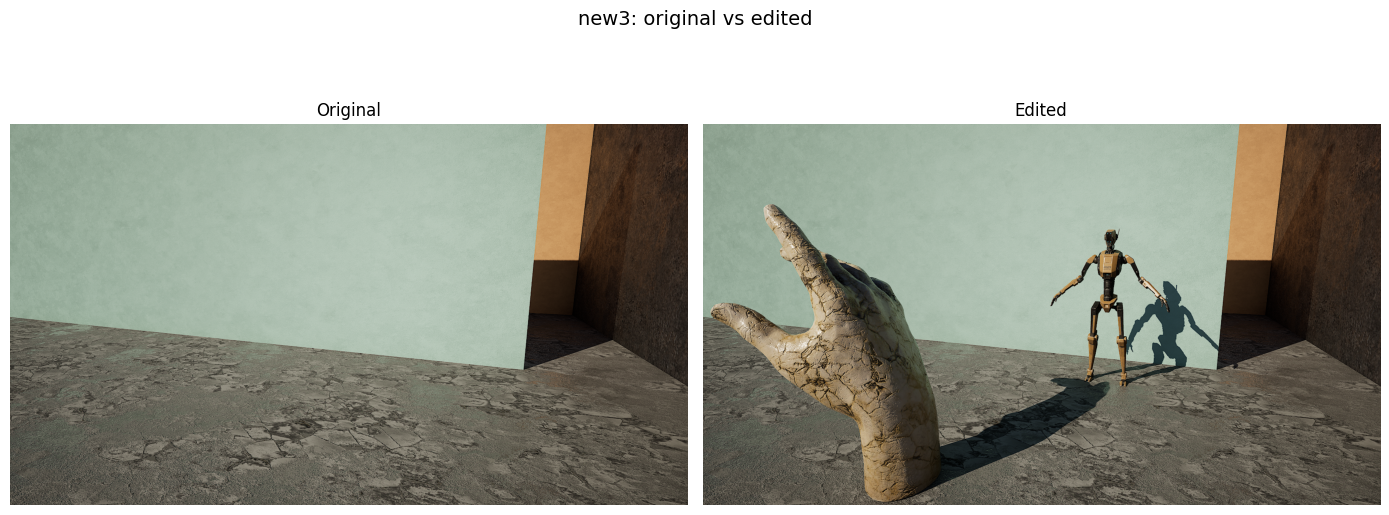

In [3]:
show_image_pair(original_img, edited_img, title=f'{DATASET}: original vs edited')


    ## Sweep 1 - `threshold`

    Other params held at the DINOv3 baseline from `params.py`.
    


  Loading DINOv3 (facebook/dinov3-vitb16-pretrain-lvd1689m) on cuda ...


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

  Loading DINOv3 (facebook/dinov3-vitb16-pretrain-lvd1689m) on cuda ...


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

  Loading DINOv3 (facebook/dinov3-vitb16-pretrain-lvd1689m) on cuda ...


...

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

  Loading DINOv3 (facebook/dinov3-vitb16-pretrain-lvd1689m) on cuda ...


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

  Loading DINOv3 (facebook/dinov3-vitb16-pretrain-lvd1689m) on cuda ...


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

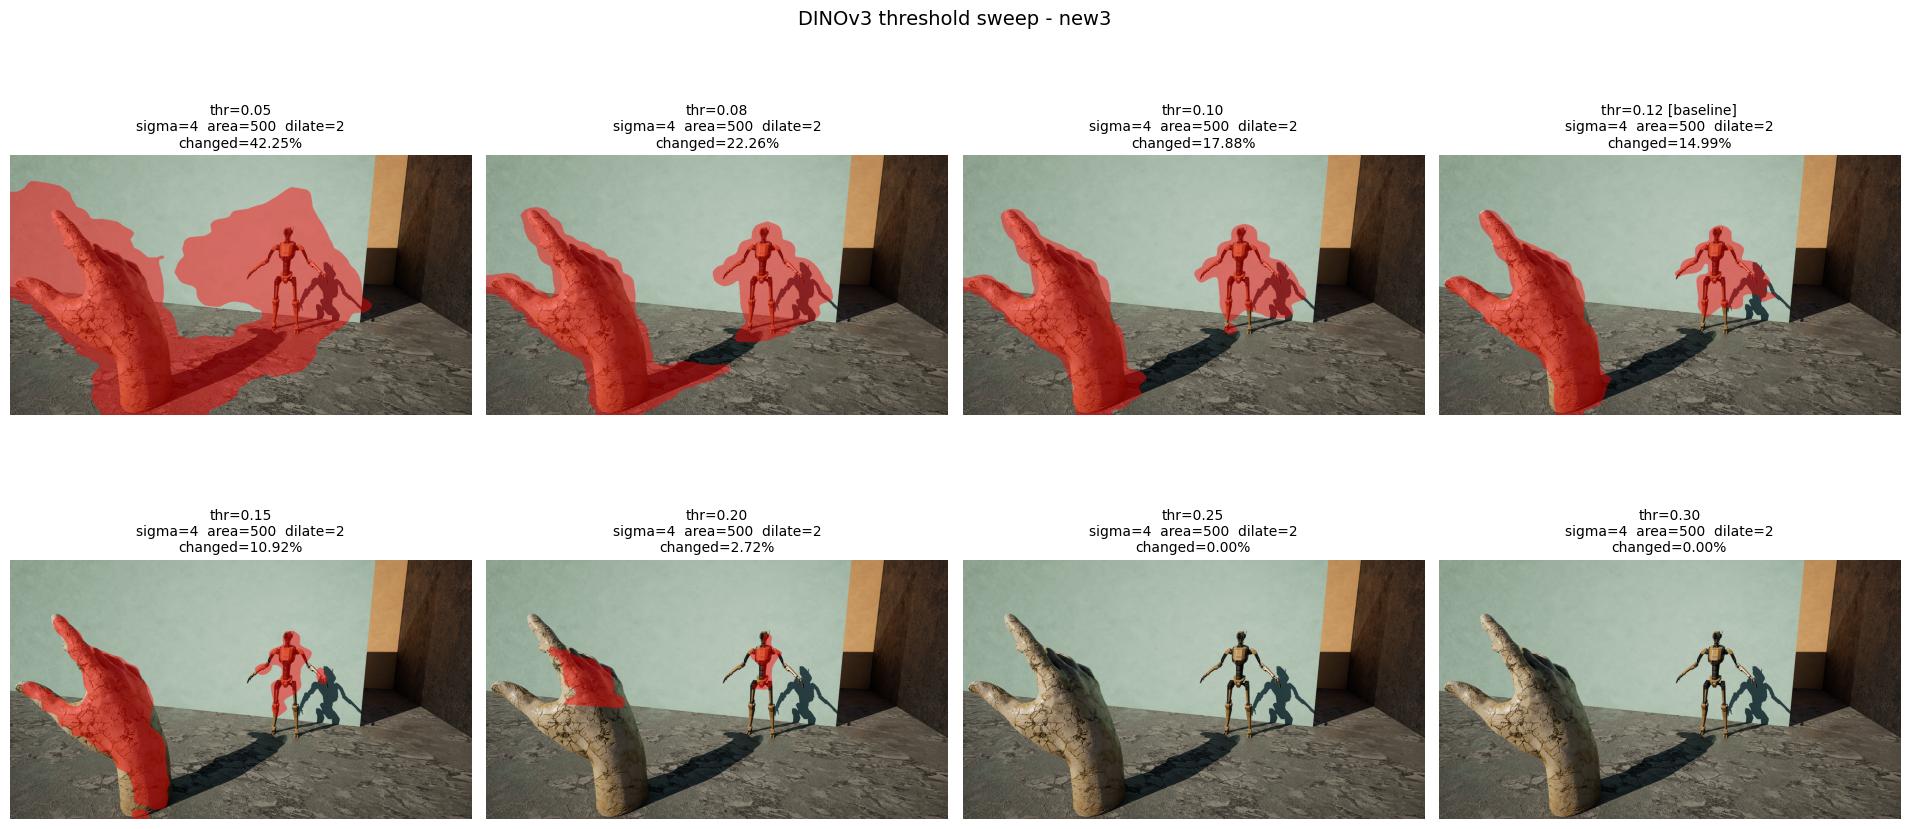

In [4]:
thr_values = [0.05, 0.08, 0.10, 0.12, 0.15, 0.20, 0.25, 0.30]
thr_results = {}

for value in thr_values:
    mask, diff_map = dinov2_feature_mask(
        original_img, edited_img,
        threshold=value,
        sigma=DINOV3_BASELINE['sigma'],
        min_area=DINOV3_BASELINE['min_area'],
        dilate_iter=DINOV3_BASELINE['dilate_iter'],
        model_name=DINOV3_BASELINE['model_name'],
    )
    thr_results[f'thr={value:.2f}'] = {
        'mask': mask,
        'diff_map': diff_map,
        'subtitle': f"sigma={DINOV3_BASELINE['sigma']}  area={DINOV3_BASELINE['min_area']}  dilate={DINOV3_BASELINE['dilate_iter']}",
    }

show_sweep(
    thr_results,
    edited_img,
    title=f'DINOv3 threshold sweep - {DATASET}',
    baseline_key=f"thr={DINOV3_BASELINE['threshold']:.2f}",
)


    ## Sweep 2 - `sigma`

    Other params: threshold, min-area and dilation stay at the DINOv3 baseline.
    


  Loading DINOv3 (facebook/dinov3-vitb16-pretrain-lvd1689m) on cuda ...


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

  Loading DINOv3 (facebook/dinov3-vitb16-pretrain-lvd1689m) on cuda ...


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

  Loading DINOv3 (facebook/dinov3-vitb16-pretrain-lvd1689m) on cuda ...


...

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

  Loading DINOv3 (facebook/dinov3-vitb16-pretrain-lvd1689m) on cuda ...


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

  Loading DINOv3 (facebook/dinov3-vitb16-pretrain-lvd1689m) on cuda ...


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

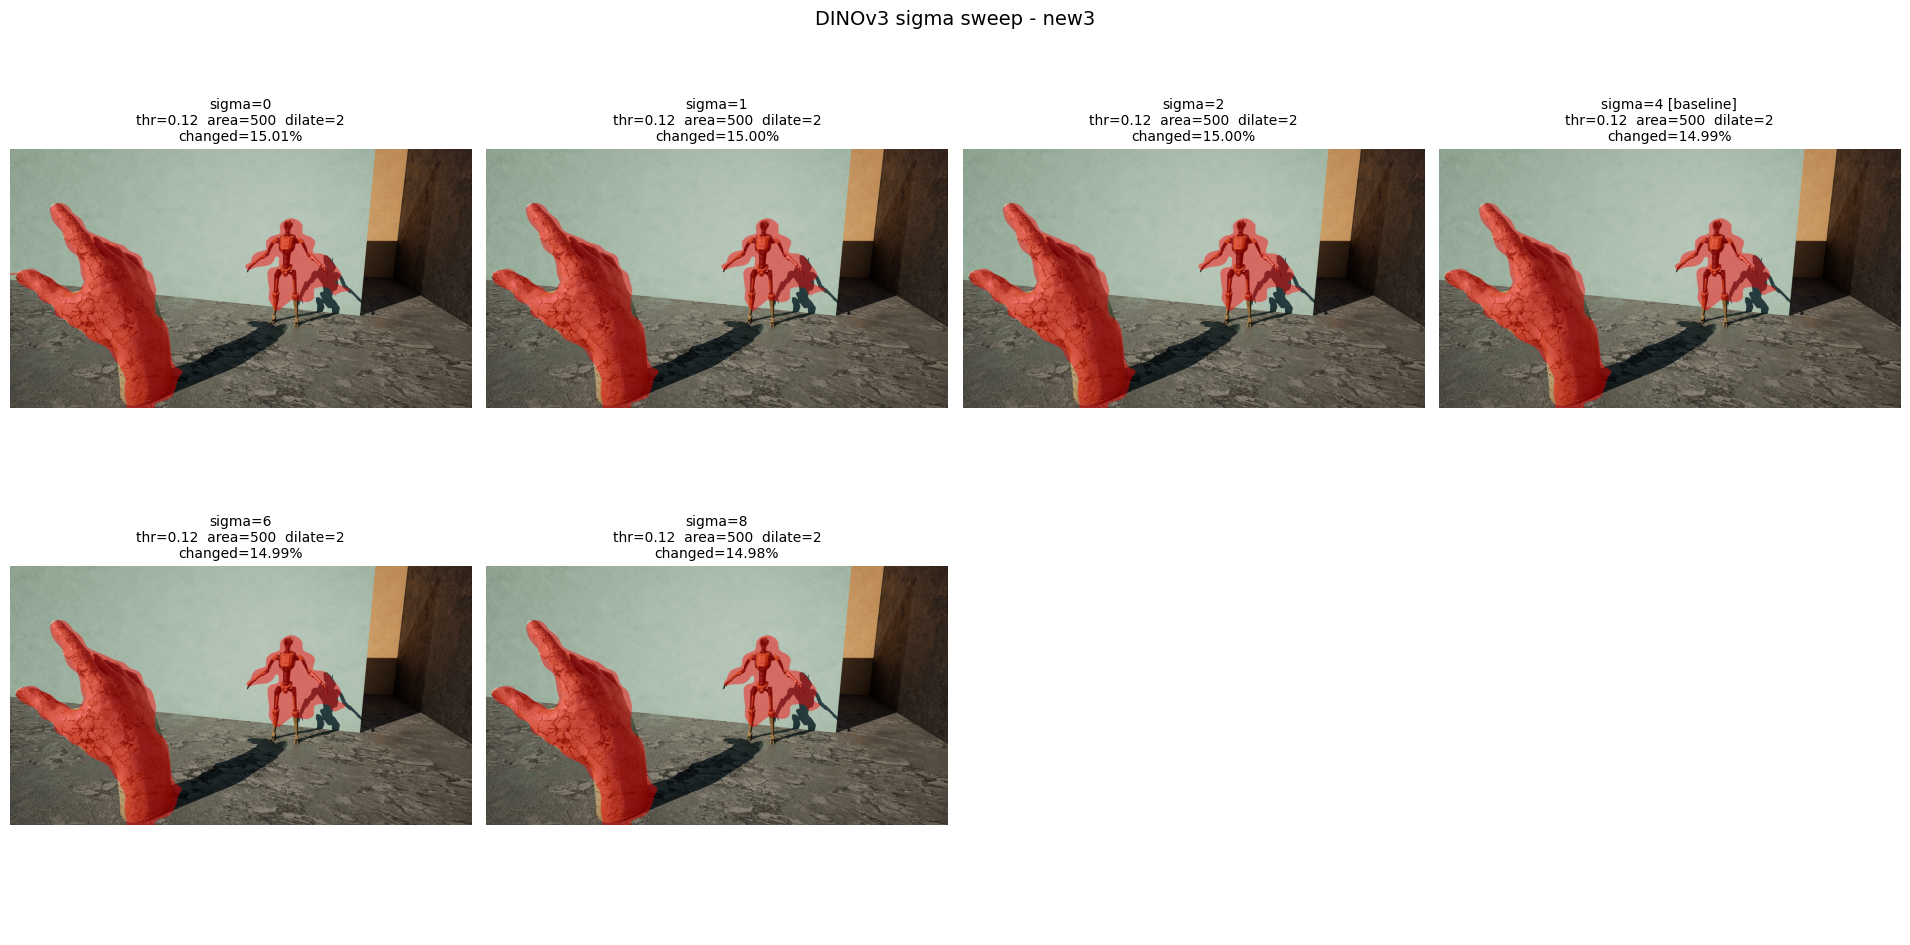

In [5]:
sigma_values = [0, 1, 2, 4, 6, 8]
sigma_results = {}

for value in sigma_values:
    mask, diff_map = dinov2_feature_mask(
        original_img, edited_img,
        threshold=DINOV3_BASELINE['threshold'],
        sigma=value,
        min_area=DINOV3_BASELINE['min_area'],
        dilate_iter=DINOV3_BASELINE['dilate_iter'],
        model_name=DINOV3_BASELINE['model_name'],
    )
    sigma_results[f'sigma={value}'] = {
        'mask': mask,
        'diff_map': diff_map,
        'subtitle': f"thr={DINOV3_BASELINE['threshold']:.2f}  area={DINOV3_BASELINE['min_area']}  dilate={DINOV3_BASELINE['dilate_iter']}",
    }

show_sweep(
    sigma_results,
    edited_img,
    title=f'DINOv3 sigma sweep - {DATASET}',
    baseline_key=f"sigma={DINOV3_BASELINE['sigma']}",
)


    ## Sweep 3 - `min_area`

    Helps trim speckle noise after thresholding and smoothing.
    


  Loading DINOv3 (facebook/dinov3-vitb16-pretrain-lvd1689m) on cuda ...


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

  Loading DINOv3 (facebook/dinov3-vitb16-pretrain-lvd1689m) on cuda ...


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

  Loading DINOv3 (facebook/dinov3-vitb16-pretrain-lvd1689m) on cuda ...


...

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

  Loading DINOv3 (facebook/dinov3-vitb16-pretrain-lvd1689m) on cuda ...


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

  Loading DINOv3 (facebook/dinov3-vitb16-pretrain-lvd1689m) on cuda ...


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

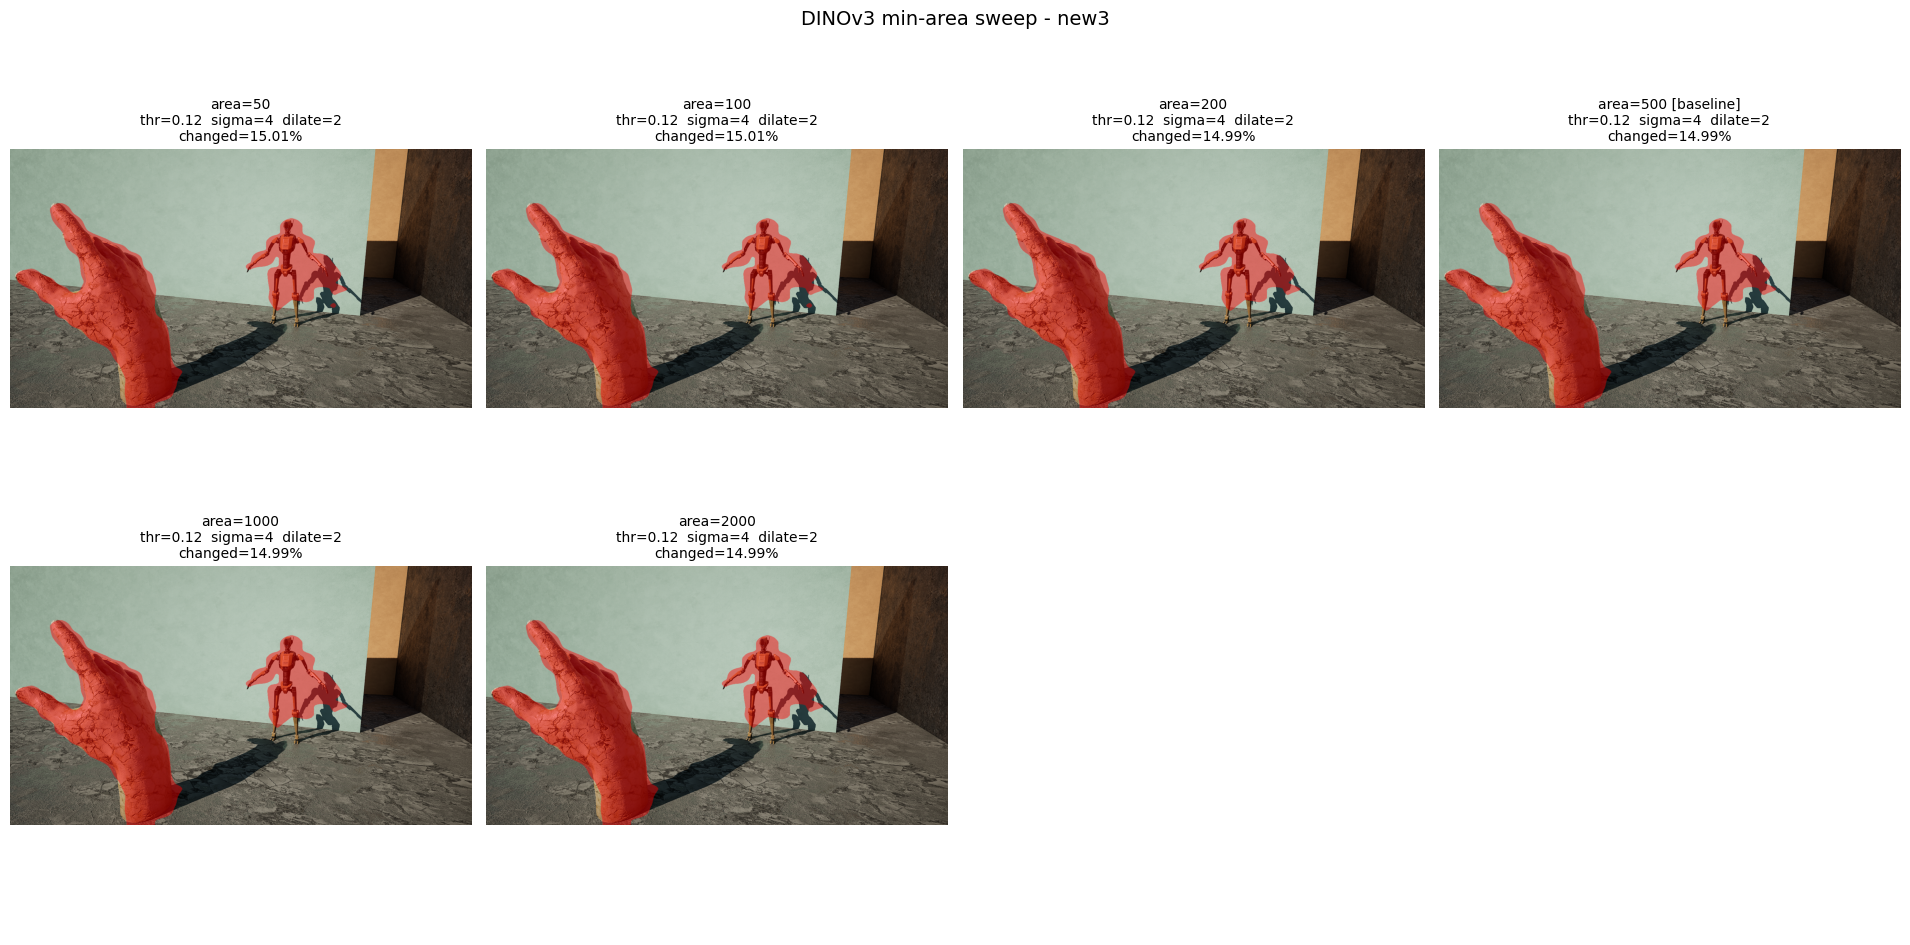

In [6]:
area_values = [50, 100, 200, 500, 1000, 2000]
area_results = {}

for value in area_values:
    mask, diff_map = dinov2_feature_mask(
        original_img, edited_img,
        threshold=DINOV3_BASELINE['threshold'],
        sigma=DINOV3_BASELINE['sigma'],
        min_area=value,
        dilate_iter=DINOV3_BASELINE['dilate_iter'],
        model_name=DINOV3_BASELINE['model_name'],
    )
    area_results[f'area={value}'] = {
        'mask': mask,
        'diff_map': diff_map,
        'subtitle': f"thr={DINOV3_BASELINE['threshold']:.2f}  sigma={DINOV3_BASELINE['sigma']}  dilate={DINOV3_BASELINE['dilate_iter']}",
    }

show_sweep(
    area_results,
    edited_img,
    title=f'DINOv3 min-area sweep - {DATASET}',
    baseline_key=f"area={DINOV3_BASELINE['min_area']}",
)


    ## Sweep 4 - `dilate_iter`

    Useful for filling holes or spreading coverage slightly after connected-component cleanup.
    


  Loading DINOv3 (facebook/dinov3-vitb16-pretrain-lvd1689m) on cuda ...


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

  Loading DINOv3 (facebook/dinov3-vitb16-pretrain-lvd1689m) on cuda ...


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

  Loading DINOv3 (facebook/dinov3-vitb16-pretrain-lvd1689m) on cuda ...


...

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

  Loading DINOv3 (facebook/dinov3-vitb16-pretrain-lvd1689m) on cuda ...


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

  Loading DINOv3 (facebook/dinov3-vitb16-pretrain-lvd1689m) on cuda ...


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

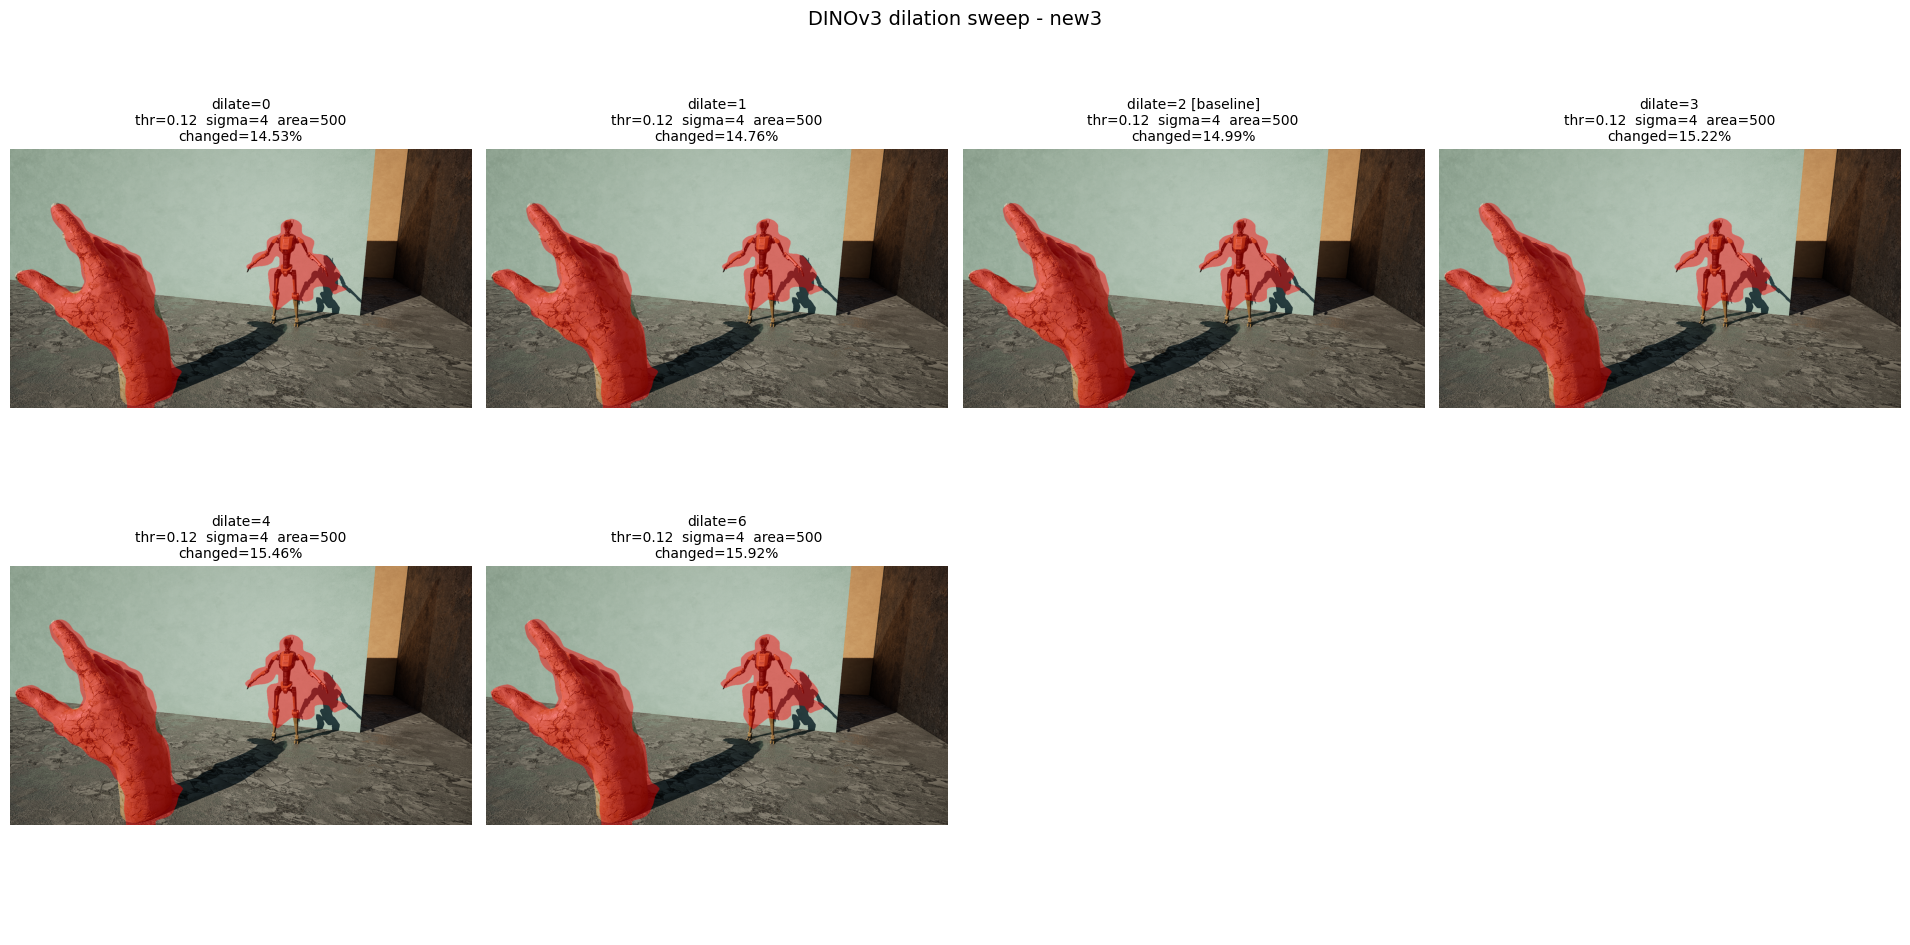

In [7]:
dilate_values = [0, 1, 2, 3, 4, 6]
dilate_results = {}

for value in dilate_values:
    mask, diff_map = dinov2_feature_mask(
        original_img, edited_img,
        threshold=DINOV3_BASELINE['threshold'],
        sigma=DINOV3_BASELINE['sigma'],
        min_area=DINOV3_BASELINE['min_area'],
        dilate_iter=value,
        model_name=DINOV3_BASELINE['model_name'],
    )
    dilate_results[f'dilate={value}'] = {
        'mask': mask,
        'diff_map': diff_map,
        'subtitle': f"thr={DINOV3_BASELINE['threshold']:.2f}  sigma={DINOV3_BASELINE['sigma']}  area={DINOV3_BASELINE['min_area']}",
    }

show_sweep(
    dilate_results,
    edited_img,
    title=f'DINOv3 dilation sweep - {DATASET}',
    baseline_key=f"dilate={DINOV3_BASELINE['dilate_iter']}",
)


    ## Combos

    Edit the non-baseline entries with the settings that looked best above, then re-run this cell.
    


  Loading DINOv3 (facebook/dinov3-vitb16-pretrain-lvd1689m) on cuda ...


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

  Loading DINOv3 (facebook/dinov3-vitb16-pretrain-lvd1689m) on cuda ...


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

  Loading DINOv3 (facebook/dinov3-vitb16-pretrain-lvd1689m) on cuda ...


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

  Loading DINOv3 (facebook/dinov3-vitb16-pretrain-lvd1689m) on cuda ...


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

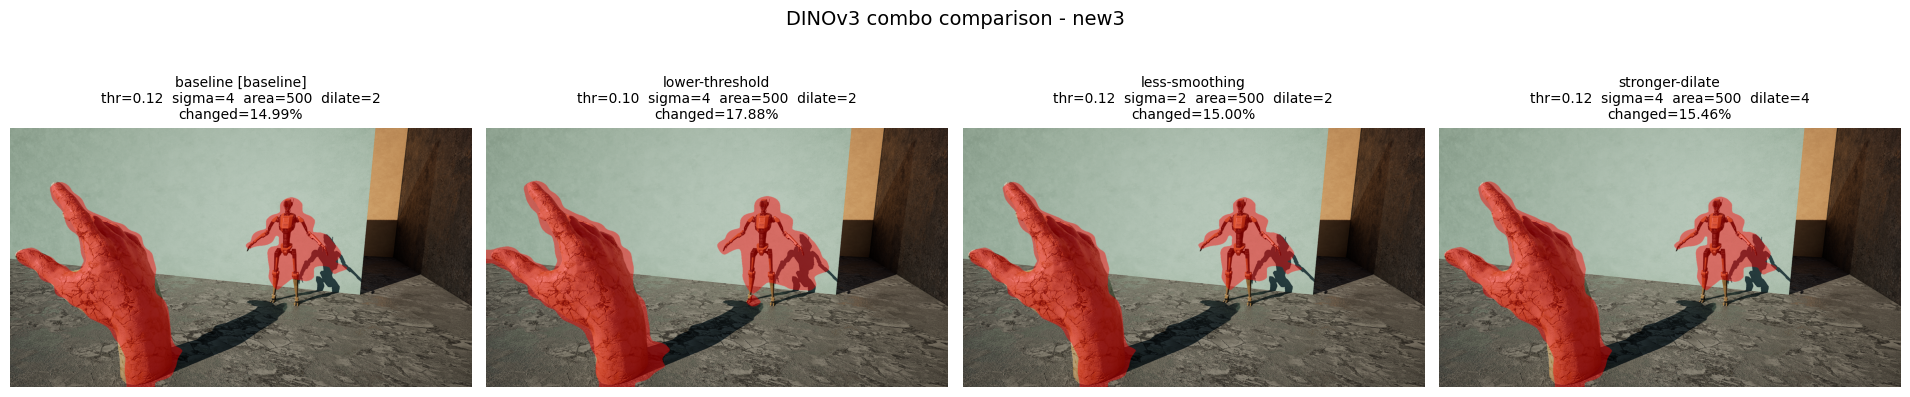

In [8]:
combo_configs = {
    'baseline': {**DINOV3_BASELINE},
    'lower-threshold': {**DINOV3_BASELINE, 'threshold': 0.10},
    'less-smoothing': {**DINOV3_BASELINE, 'sigma': 2},
    'stronger-dilate': {**DINOV3_BASELINE, 'dilate_iter': 4},
}

combo_results = {}
for name, cfg in combo_configs.items():
    mask, diff_map = dinov2_feature_mask(
        original_img, edited_img,
        threshold=cfg['threshold'],
        sigma=cfg['sigma'],
        min_area=cfg['min_area'],
        dilate_iter=cfg['dilate_iter'],
        model_name=cfg['model_name'],
    )
    combo_results[name] = {
        'mask': mask,
        'diff_map': diff_map,
        'subtitle': (
            f"thr={cfg['threshold']:.2f}  sigma={cfg['sigma']}  "
            f"area={cfg['min_area']}  dilate={cfg['dilate_iter']}"
        ),
    }

show_sweep(combo_results, edited_img, title=f'DINOv3 combo comparison - {DATASET}', baseline_key='baseline')

In [9]:
gc.collect()
if device == 'cuda':
    torch.cuda.empty_cache()
